# Regressão linear do zero

**Tema:** Aprendizado Supervisionado › Regressão Linear

Este notebook implementa regressão linear de duas formas — via equações
normais (QR, como no tema 2) e via gradiente descendente (como no tema 2,
módulo 3) — e confirma que batem com `sklearn.LinearRegression`. Depois
constrói, na mão, os erros-padrão e intervalos de confiança dos
coeficientes, para deixar claro de onde eles vêm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(1)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Dados sintéticos com coeficientes conhecidos

In [2]:
n, p = 500, 3
X_bruto = rng.normal(0, 1, (n, p))
beta_real = np.array([5.0, 2.5, -1.8, 0.9])  # intercepto + 3 coeficientes
X = np.column_stack([np.ones(n), X_bruto])
sigma_real = 1.5
y = X @ beta_real + rng.normal(0, sigma_real, n)

print(f"beta real: {beta_real}")

beta real: [ 5.   2.5 -1.8  0.9]


## 2. Três formas de ajustar, todas devem bater

In [3]:
# via QR (equações normais estáveis, tema 2)
Q, R = np.linalg.qr(X)
beta_qr = np.linalg.solve(R, Q.T @ y)

# via gradiente descendente (tema 2, módulo 3)
def gd_regressao(X, y, eta, n_epocas):
    beta = np.zeros(X.shape[1])
    for _ in range(n_epocas):
        residuo = X @ beta - y
        grad = (2 / len(y)) * X.T @ residuo
        beta = beta - eta * grad
    return beta


# features já padronizadas o suficiente (média 0, variância ~1) para uma
# taxa de aprendizado razoável convergir sem pré-condicionamento extra
beta_gd = gd_regressao(X, y, eta=0.05, n_epocas=3000)

# via sklearn
modelo_sklearn = LinearRegression(fit_intercept=False).fit(X, y)
beta_sklearn = modelo_sklearn.coef_

print(f"{'método':<20s} {'coeficientes':>50s}")
print("-" * 74)
for nome, b in [("verdadeiro", beta_real), ("QR", beta_qr),
                ("gradiente descendente", beta_gd), ("sklearn", beta_sklearn)]:
    print(f"{nome:<20s} {np.array2string(b, precision=4):>50s}")

método                                                     coeficientes
--------------------------------------------------------------------------
verdadeiro                                        [ 5.   2.5 -1.8  0.9]
QR                                    [ 5.1451  2.5154 -1.9462  1.0801]
gradiente descendente                  [ 5.1451  2.5154 -1.9462  1.0801]
sklearn                               [ 5.1451  2.5154 -1.9462  1.0801]


## 3. Erros-padrão e intervalos de confiança, na mão

$\hat\sigma^2 = \text{SQR}/(n-p-1)$, e a matriz de covariância dos
coeficientes é $\hat\sigma^2 (X^\top X)^{-1}$ — calculada de forma estável
via $R^{-1}R^{-\top}$, sem nunca formar $X^\top X$ (tema 2).

In [4]:
def regressao_com_inferencia(X, y, nomes=None):
    n, p_mais_1 = X.shape
    gl = n - p_mais_1
    nomes = nomes or [f"x{i}" for i in range(p_mais_1)]

    Q, R = np.linalg.qr(X)
    beta = np.linalg.solve(R, Q.T @ y)
    y_hat = X @ beta
    residuos = y - y_hat

    sigma2 = (residuos @ residuos) / gl
    R_inv = np.linalg.inv(R)
    cov_beta = sigma2 * (R_inv @ R_inv.T)
    erro_padrao = np.sqrt(np.diag(cov_beta))

    t_stat = beta / erro_padrao
    p_valores = 2 * stats.t.sf(np.abs(t_stat), gl)
    t_critico = stats.t.ppf(0.975, gl)
    ic_inferior = beta - t_critico * erro_padrao
    ic_superior = beta + t_critico * erro_padrao

    sqt = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (residuos @ residuos) / sqt
    r2_ajustado = 1 - (1 - r2) * (n - 1) / gl

    tabela = pd.DataFrame({
        "coeficiente": beta, "erro_padrao": erro_padrao, "t": t_stat,
        "p_valor": p_valores, "IC_2.5%": ic_inferior, "IC_97.5%": ic_superior,
    }, index=nomes)
    return tabela, r2, r2_ajustado, residuos, y_hat


nomes_colunas = ["intercepto", "x1", "x2", "x3"]
tabela, r2, r2_aj, residuos, y_hat = regressao_com_inferencia(X, y, nomes_colunas)
print(tabela.round(4).to_string())
print(f"\nR² = {r2:.4f}   R² ajustado = {r2_aj:.4f}")
print(f"\ncoeficientes verdadeiros: {beta_real}")
print("Note que os ICs de 95% capturam o valor verdadeiro na maioria das vezes")
print("(é exatamente a garantia frequentista do tema 1: 95% dos INTERVALOS")
print("construídos assim capturam o parâmetro real, não que ESTE intervalo")
print("específico tem 95% de chance de conter o valor).")

            coeficiente  erro_padrao        t  p_valor  IC_2.5%  IC_97.5%
intercepto       5.1451       0.0667  77.1087      0.0   5.0140    5.2762
x1               2.5154       0.0660  38.1253      0.0   2.3857    2.6450
x2              -1.9462       0.0673 -28.9398      0.0  -2.0783   -1.8141
x3               1.0801       0.0647  16.6990      0.0   0.9530    1.2072

R² = 0.8402   R² ajustado = 0.8393

coeficientes verdadeiros: [ 5.   2.5 -1.8  0.9]
Note que os ICs de 95% capturam o valor verdadeiro na maioria das vezes
(é exatamente a garantia frequentista do tema 1: 95% dos INTERVALOS
construídos assim capturam o parâmetro real, não que ESTE intervalo
específico tem 95% de chance de conter o valor).


## 4. R² nunca diminui ao adicionar features — mesmo ruído puro

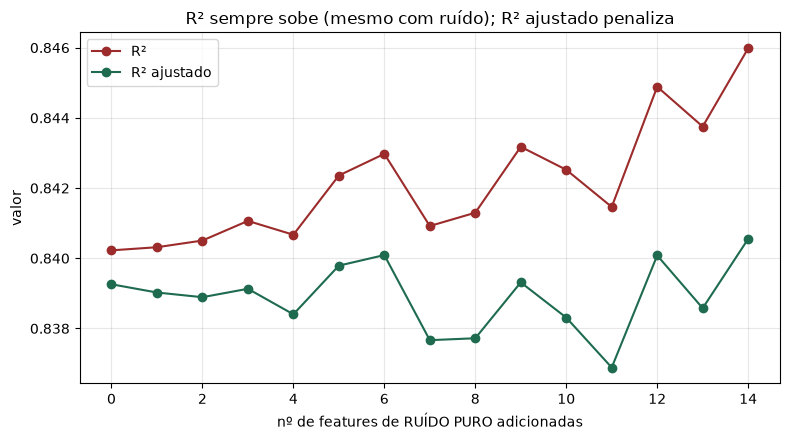

In [5]:
r2s, r2s_ajustados = [], []
n_features_ruido = range(0, 15)
for k in n_features_ruido:
    ruido_extra = rng.normal(0, 1, (n, k))
    X_com_ruido = np.column_stack([X, ruido_extra])
    _, r2_k, r2_aj_k, _, _ = regressao_com_inferencia(
        X_com_ruido, y, [f"c{i}" for i in range(X_com_ruido.shape[1])])
    r2s.append(r2_k)
    r2s_ajustados.append(r2_aj_k)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(n_features_ruido), r2s, "o-", color=VERMELHO, label="R²")
ax.plot(list(n_features_ruido), r2s_ajustados, "o-", color=VERDE, label="R² ajustado")
ax.set_xlabel("nº de features de RUÍDO PURO adicionadas")
ax.set_ylabel("valor")
ax.set_title("R² sempre sobe (mesmo com ruído); R² ajustado penaliza")
ax.legend(); plt.tight_layout(); plt.show()

## O que levar deste notebook

- As três formas de ajustar (QR, gradiente descendente, sklearn) convergem
  para os mesmos coeficientes — são o mesmo problema de otimização visto
  nos temas 2 e 3, resolvido de formas diferentes.
- Erros-padrão e intervalos de confiança saem diretamente de
  $\hat\sigma^2(X^\top X)^{-1}$, calculado com estabilidade via QR.
- $R^2$ sobe mesmo adicionando puro ruído — nunca o use sozinho para decidir
  se uma feature vale a pena.

→ Próximo: **Pressupostos e diagnóstico**, o que fazer quando LINE não vale.